<a href="https://colab.research.google.com/github/dharshini221023/ATM-Mangement/blob/main/recursive_feature_elimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.feature_selection import RFE

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import xgboost as xgb


In [2]:
data = pd.read_csv("/content/drive/MyDrive/ML Experiment/gallstone.csv")


In [3]:
X = data.drop("Gallstone Status", axis=1)
y = data["Gallstone Status"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)



In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
rfe_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=15
)

rfe.fit(X_train_scaled, y_train)

selected_features = X.columns[rfe.support_]

print("\nSelected Features:")
print(selected_features)


X_train_sel = pd.DataFrame(X_train_scaled, columns=X.columns)[selected_features]
X_test_sel = pd.DataFrame(X_test_scaled, columns=X.columns)[selected_features]



Selected Features:
Index(['Extracellular Water (ECW)', 'Intracellular Water (ICW)',
       'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Lean Mass (LM) (%)',
       'Body Protein Content (Protein) (%)', 'Bone Mass (BM)', 'Obesity (%)',
       'Visceral Fat Area (VFA)', 'Visceral Muscle Area (VMA) (Kg)',
       'Aspartat Aminotransferaz (AST)', 'Creatinine',
       'Glomerular Filtration Rate (GFR)', 'C-Reactive Protein (CRP)',
       'Hemoglobin (HGB)', 'Vitamin D'],
      dtype='object')


In [7]:
rf = RandomForestClassifier(
    n_estimators=600,
    class_weight="balanced",
    random_state=42
)

xgb_model = xgb.XGBClassifier(
    n_estimators=700,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

svm = SVC(
    probability=True,
    kernel="rbf",
    C=5
)

lr = LogisticRegression(
    max_iter=3000
)

In [8]:
ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb_model),
        ("svm", svm),
        ("lr", lr)
    ],
    voting="soft"
)

ensemble.fit(X_train_sel, y_train)


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=600,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=No...
                                            learning_rate=0.03, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=700, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('svm', SVC(C=5, probability=True)),
                             ('lr', LogisticRegression(max_iter=3000))],
                 voting='soft')

In [9]:

y_prob = ensemble.predict_proba(X_test_sel)[:,1]

In [10]:

best_acc = 0
best_t = 0

for t in np.arange(0.2,0.8,0.01):

    y_pred = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred)

    if acc > best_acc:
        best_acc = acc
        best_t = t


print("\nBest Threshold:", best_t)
print("Best Accuracy:", best_acc)


Best Threshold: 0.36000000000000015
Best Accuracy: 0.890625


In [11]:

y_pred = (y_prob >= best_t).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.81      0.88        32
           1       0.84      0.97      0.90        32

    accuracy                           0.89        64
   macro avg       0.90      0.89      0.89        64
weighted avg       0.90      0.89      0.89        64


Confusion Matrix:
[[26  6]
 [ 1 31]]


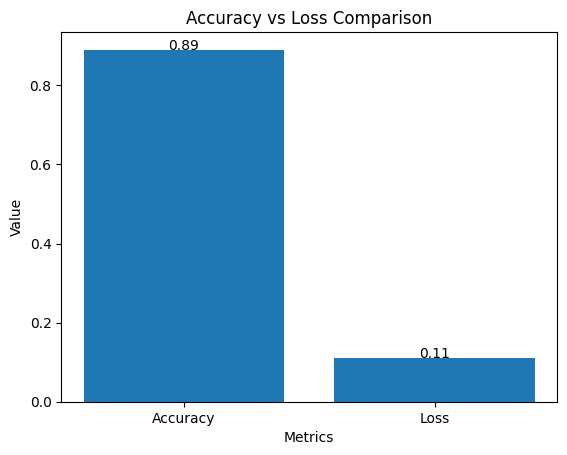

In [12]:
import matplotlib.pyplot as plt

# Values
labels = ["Accuracy", "Loss"]
values = [0.89, 0.11]

x = range(len(labels))

plt.figure()

plt.bar(x, values)

# Add values on bars
for i in range(len(values)):
    plt.text(i, values[i], f"{values[i]:.2f}", ha='center')

plt.xticks(x, labels)
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Accuracy vs Loss Comparison")

plt.show()

<Figure size 640x480 with 0 Axes>

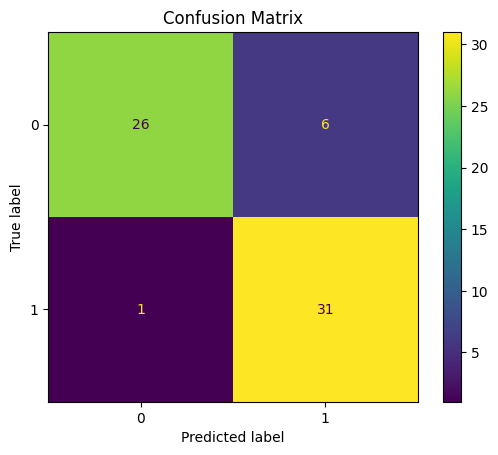

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure()
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [15]:
print(X.columns.tolist())

['Age', 'Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)', 'Height', 'Weight', 'Body Mass Index (BMI)', 'Total Body Water (TBW)', 'Extracellular Water (ECW)', 'Intracellular Water (ICW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)', 'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)', 'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)', 'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)', 'Visceral Muscle Area (VMA) (Kg)', 'Hepatic Fat Accumulation (HFA)', 'Glucose', 'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)', 'High Density Lipoprotein (HDL)', 'Triglyceride', 'Aspartat Aminotransferaz (AST)', 'Alanin Aminotransferaz (ALT)', 'Alkaline Phosphatase (ALP)', 'Creatinine', 'Glomerular Filtration Rate (GFR)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']


In [16]:
new_patient = pd.DataFrame([{
    'Age': 45,
    'Gender': 1,
    'Comorbidity': 0,
    'Coronary Artery Disease (CAD)': 0,
    'Hypothyroidism': 0,
    'Hyperlipidemia': 1,
    'Diabetes Mellitus (DM)': 0,
    'Height': 165,
    'Weight': 70,
    'Body Mass Index (BMI)': 25.7,
    'Total Body Water (TBW)': 35,
    'Extracellular Water (ECW)': 17.5,
    'Intracellular Water (ICW)': 23.0,
    'Extracellular Fluid/Total Body Water (ECF/TBW)': 0.39,
    'Total Body Fat Ratio (TBFR) (%)': 28,
    'Lean Mass (LM) (%)': 68,
    'Body Protein Content (Protein) (%)': 17,
    'Visceral Fat Rating (VFR)': 10,
    'Bone Mass (BM)': 3.2,
    'Muscle Mass (MM)': 50,
    'Obesity (%)': 28,
    'Total Fat Content (TFC)': 20,
    'Visceral Fat Area (VFA)': 115,
    'Visceral Muscle Area (VMA) (Kg)': 28,
    'Hepatic Fat Accumulation (HFA)': 8,
    'Glucose': 100,
    'Total Cholesterol (TC)': 180,
    'Low Density Lipoprotein (LDL)': 110,
    'High Density Lipoprotein (HDL)': 45,
    'Triglyceride': 150,
    'Aspartat Aminotransferaz (AST)': 42,
    'Alanin Aminotransferaz (ALT)': 40,
    'Alkaline Phosphatase (ALP)': 90,
    'Creatinine': 1.1,
    'Glomerular Filtration Rate (GFR)': 85,
    'C-Reactive Protein (CRP)': 6.5,
    'Hemoglobin (HGB)': 13.5,
    'Vitamin D': 18
}])
# Scale all 39 features
new_patient_scaled = scaler.transform(new_patient)

new_patient_scaled = pd.DataFrame(
    new_patient_scaled,
    columns=X.columns
)

# Select RFE features
new_patient_sel = new_patient_scaled[selected_features]

# Predict
prob = ensemble.predict_proba(new_patient_sel)[0][1]

pred = 1 if prob >= best_t else 0

print("Gallstone Probability:", round(prob, 4))

if pred == 1:
    print("Gallstone Detected")
else:
    print("No Gallstone")

Gallstone Probability: 0.8596
Gallstone Detected
